## FLIGHT RISK

### Exploratory Data Analysis (EDA)

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from dotenv import load_dotenv

In [2]:
load_dotenv()
START_YEAR = os.environ.get('START_YEAR')
END_YEAR = os.environ.get('END_YEAR')

columns_mapping = {
    "ICAO Empresa Aérea": "airline_icao",
    "Número Voo": "flight_id",
    "Código Autorização (DI)": "authorization_code",
    "Código Tipo Linha": "flight_type_code",
    "ICAO Aeródromo Origem": "origin_icao",
    "ICAO Aeródromo Destino": "destination_icao",
    "Partida Prevista": "dep_scheduled",
    "Partida Real": "dep_actual",
    "Chegada Prevista": "arr_scheduled",
    "Chegada Real": "arr_actual",
    "Situação Voo": "flight_status",
    "Código Justificativa": "delay_reason_code"
}
datetime_cols = [
    "dep_scheduled",
    "dep_actual",
    "arr_scheduled",
    "arr_actual"
]
br_prefixes = "SB"

In [3]:
data = pd.read_csv(
    f"../.data/vra_{START_YEAR}_to_{END_YEAR}.csv",
    sep=";",
    low_memory=False
)

In [4]:
# Rename cols to convention format
data = data.rename(columns=columns_mapping)

# Convert DateTime columns
data[datetime_cols] = (
    data[datetime_cols].apply(
        lambda col: pd.to_datetime(col, format="ISO8601") \
        # lambda col: pd.to_datetime(col, format="mixed", dayfirst=True, errors="coerce") \
        .dt.floor("s") \
        .astype("datetime64[ns]")
    )
)

In [5]:
data.shape

(3851504, 12)

In [6]:
data.head()

,airline_icao,flight_id,authorization_code,flight_type_code,origin_icao,destination_icao,dep_scheduled,dep_actual,arr_scheduled,arr_actual,flight_status,delay_reason_code
0,TAM,3633,0,N,SBRJ,SBGR,2022-01-06 14:20:00,2022-01-06 14:31:00,2022-01-06 15:25:00,2022-01-06 15:29:00,REALIZADO,NaN
1,TAM,3633,0,N,SBRJ,SBGR,2022-01-07 14:20:00,2022-01-07 14:47:00,2022-01-07 15:25:00,2022-01-07 15:42:00,REALIZADO,NaN
2,TAM,3633,0,N,SBRJ,SBGR,2022-01-08 14:20:00,2022-01-08 14:12:00,2022-01-08 15:25:00,2022-01-08 15:12:00,REALIZADO,NaN
3,TAM,3633,0,N,SBRJ,SBGR,2022-01-09 14:20:00,2022-01-09 14:16:00,2022-01-09 15:25:00,2022-01-09 15:15:00,REALIZADO,NaN
4,TAM,3633,0,N,SBRJ,SBGR,2022-01-11 14:20:00,2022-01-11 14:20:00,2022-01-11 15:25:00,2022-01-11 15:15:00,REALIZADO,NaN


In [7]:
# Domestic Flights only (BR->BR)

mask_domestic_flight = (
    data["origin_icao"].str.startswith(br_prefixes, na=False)
    & data["destination_icao"].str.startswith(br_prefixes, na=False)
)

data_domestic = data.loc[mask_domestic_flight].copy()
data_domestic.shape

(3157581, 12)

#### Data Quality

In [8]:
data_domestic.shape

(3157581, 12)

In [9]:
data_domestic.dtypes

airline_icao                     str
flight_id                        str
authorization_code               str
flight_type_code                 str
origin_icao                      str
destination_icao                 str
dep_scheduled         datetime64[ns]
dep_actual            datetime64[ns]
arr_scheduled         datetime64[ns]
arr_actual            datetime64[ns]
flight_status                    str
delay_reason_code            float64
dtype: object

In [10]:
# Missing Values

pd.concat([
    data_domestic.isna().sum().rename("missing_count"),
    (data_domestic.isna().mean() * 100).round(2).rename("missing_pct")
], axis=1).sort_values("missing_pct", ascending=False)

,missing_count,missing_pct
delay_reason_code,3157581,100.00
dep_scheduled,83087,2.63
dep_actual,83105,2.63
arr_scheduled,83087,2.63
arr_actual,83105,2.63
flight_type_code,219,0.01
airline_icao,0,0.00
flight_id,0,0.00
authorization_code,0,0.00
destination_icao,0,0.00


In [11]:
# NOTE: the 'dep_actual' is NA because the flight was cancelled.

data_domestic[
    data_domestic["dep_actual"].isna()
]["flight_status"].value_counts()

flight_status
CANCELADO        82665
NÃO INFORMADO      440
Name: count, dtype: int64

In [12]:
# NOTE: the 'arr_actual' is NA because the flight was cancelled.

data_domestic[
    data_domestic["arr_actual"].isna()
]["flight_status"].value_counts()

flight_status
CANCELADO        82665
NÃO INFORMADO      440
Name: count, dtype: int64

In [13]:
# Flight status

data_domestic["flight_status"].value_counts()

flight_status
REALIZADO        3074476
CANCELADO          82665
NÃO INFORMADO        440
Name: count, dtype: int64

In [14]:
# Duplicated Values

data_domestic.duplicated().sum()

np.int64(1)

In [15]:
data_domestic = data_domestic.drop_duplicates()

In [16]:
# NOTE: only flights that have been carried out should be considered to calculate the delay
# NOTE: use the 'data_delay' df to modeling

data_delay = data_domestic.loc[
    data_domestic["flight_status"] == "REALIZADO"
].copy()

In [17]:
data_delay.shape

(3074476, 12)

#### Target Analysis

In [18]:
# Arrival delay

data_delay["arr_delay_min"] = (
    data_delay["arr_actual"] - data_delay["arr_scheduled"]
).dt.total_seconds() / 60

In [19]:
# Departure delay
data_delay["dep_delay_min"]= (
    data_delay["dep_actual"] - data_delay["dep_scheduled"]
).dt.total_seconds() / 60

In [20]:
# NOTE: negative values == before scheduled time
# NOTE: the passenger notices the arrive delay, so arr_delay will be the TARGET

data_delay[["dep_delay_min", "arr_delay_min"]]

,dep_delay_min,arr_delay_min
0,11.0,4.0
1,27.0,17.0
2,-8.0,-13.0
3,-4.0,-10.0
4,0.0,-10.0
...,...,...
3851499,-4.0,-11.0
3851500,-6.0,-9.0
3851501,-9.0,-9.0
3851502,-8.0,-14.0


In [21]:
# Data basic Stats
print(
    (
        f"Mean -> {data_delay["arr_delay_min"].mean()} \n"
        f"Min -> {data_delay["arr_delay_min"].min()} \n"
        f"Max -> {data_delay["arr_delay_min"].max()} \n"
        f"STD -> {data_delay["arr_delay_min"].std()} \n"
    )
)

Mean -> 1.9865005855139535 
Min -> -524907.0 
Max -> 4605.0 
STD -> 306.1886169041028 



In [22]:
data_delay["arr_delay_min"].quantile(
    [0.5, 0.75, 0.9, 0.95, 0.99]
)

0.50     -4.0
0.75      7.0
0.90     24.0
0.95     42.0
0.99    114.0
Name: arr_delay_min, dtype: float64

In [23]:
data_delay["arr_delay_min"].describe(
    percentiles=[0.90, 0.95, 0.99, 0.999]
)

count    2.991389e+06
mean     1.986501e+00
std      3.061886e+02
min     -5.249070e+05
90%      2.400000e+01
95%      4.200000e+01
99%      1.140000e+02
99.9%    3.300000e+02
max      4.605000e+03
Name: arr_delay_min, dtype: float64

In [24]:
data_delay.nsmallest(10, "arr_delay_min")[
    [
        "arr_scheduled",
        "arr_actual",
        "arr_delay_min"
    ]
]

,arr_scheduled,arr_actual,arr_delay_min
1002269,2023-02-12 02:05:00,2022-02-12 13:38:00,-524907.0
1896616,2024-02-03 09:15:00,2024-01-31 09:16:00,-4319.0
3242293,2025-06-01 00:50:00,2025-05-30 00:06:00,-2924.0
2081527,2024-03-15 06:20:00,2024-03-13 06:27:00,-2873.0
2082125,2024-04-02 08:20:00,2024-03-31 08:52:00,-2848.0
2462739,2024-08-22 06:50:00,2024-08-20 07:35:00,-2835.0
2297415,2024-06-14 17:05:00,2024-06-12 18:18:00,-2807.0
2081526,2024-03-08 06:20:00,2024-03-06 07:41:00,-2799.0
2091361,2024-03-29 06:20:00,2024-03-27 09:31:00,-2689.0
3461192,2025-08-18 04:55:00,2025-08-17 00:41:00,-1694.0


In [25]:
data_delay.nlargest(10, "arr_delay_min")[
    [
        "arr_scheduled",
        "arr_actual",
        "arr_delay_min"
    ]
]

,arr_scheduled,arr_actual,arr_delay_min
2360689,2024-07-09 06:50:00,2024-07-12 11:35:00,4605.0
3636446,2025-10-28 16:25:00,2025-10-31 19:20:00,4495.0
423698,2022-07-26 16:35:00,2022-07-29 05:55:00,3680.0
423697,2022-07-19 16:35:00,2022-07-21 16:40:00,2885.0
423713,2022-07-19 19:00:00,2022-07-21 19:05:00,2885.0
2852067,2025-01-25 02:05:00,2025-01-27 01:51:00,2866.0
2852061,2025-01-18 02:05:00,2025-01-20 01:44:00,2859.0
2852055,2025-01-11 02:05:00,2025-01-13 01:41:00,2856.0
2851929,2025-01-04 02:05:00,2025-01-06 01:39:00,2854.0
2733802,2024-11-07 20:20:00,2024-11-09 18:49:00,2789.0


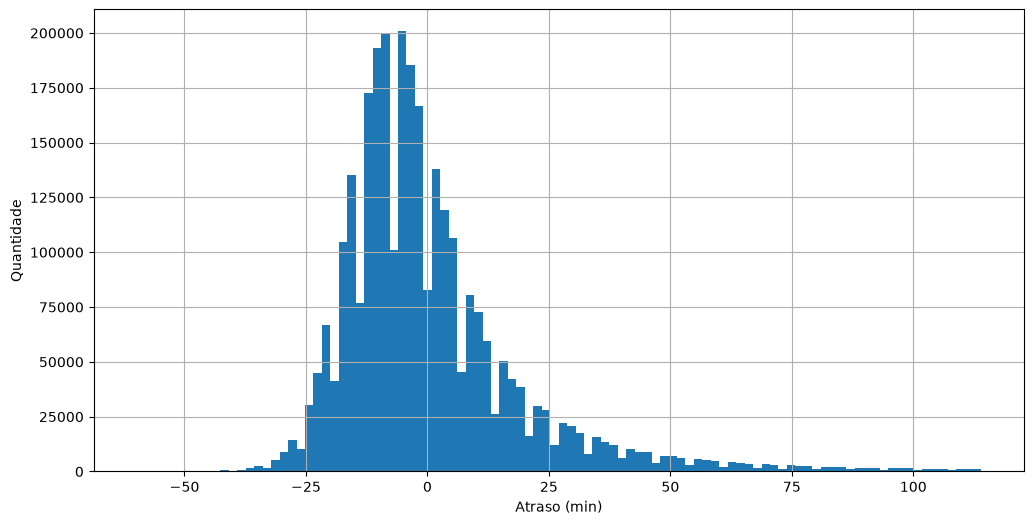

In [26]:
p99 = data_delay["arr_delay_min"].quantile(0.99)

plt.figure(figsize=(12, 6))

data_delay.loc[
    data_delay["arr_delay_min"].between(-60, p99),
    "arr_delay_min"
].hist(bins=100)

plt.xlabel("Atraso (min)")
plt.ylabel("Quantidade")
plt.show()

<Axes: ylabel='arr_delay_min'>

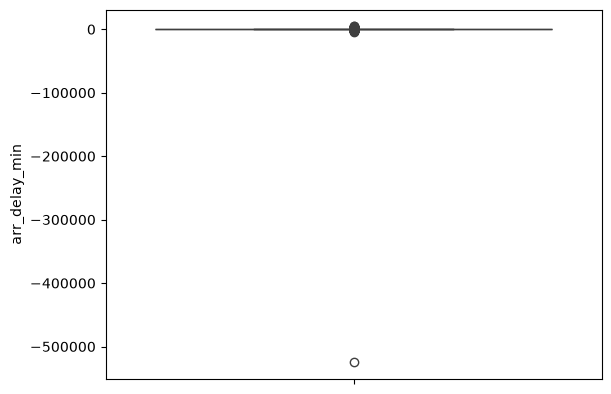

In [27]:
sns.boxplot(data_delay["arr_delay_min"])

In [28]:
data_delay[
    data_delay["arr_delay_min"] < -1440
].shape

(177, 14)

In [29]:
data_delay[
    data_delay["arr_delay_min"] > 1440
].shape

(98, 14)

In [30]:
data_delay = data_delay[
    data_delay["arr_delay_min"].between(
        -1440,
        1440
    )
].copy()

<Axes: ylabel='arr_delay_min'>

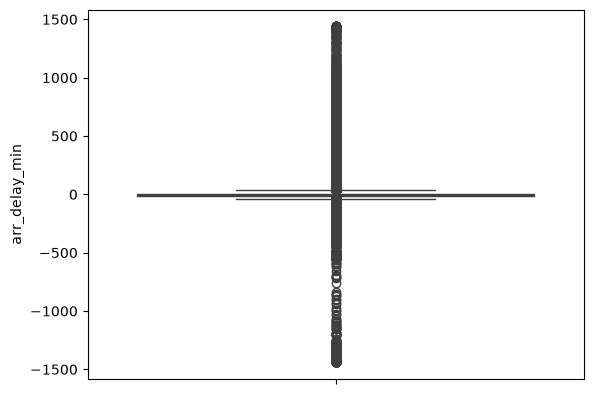

In [31]:
sns.boxplot(data_delay["arr_delay_min"])

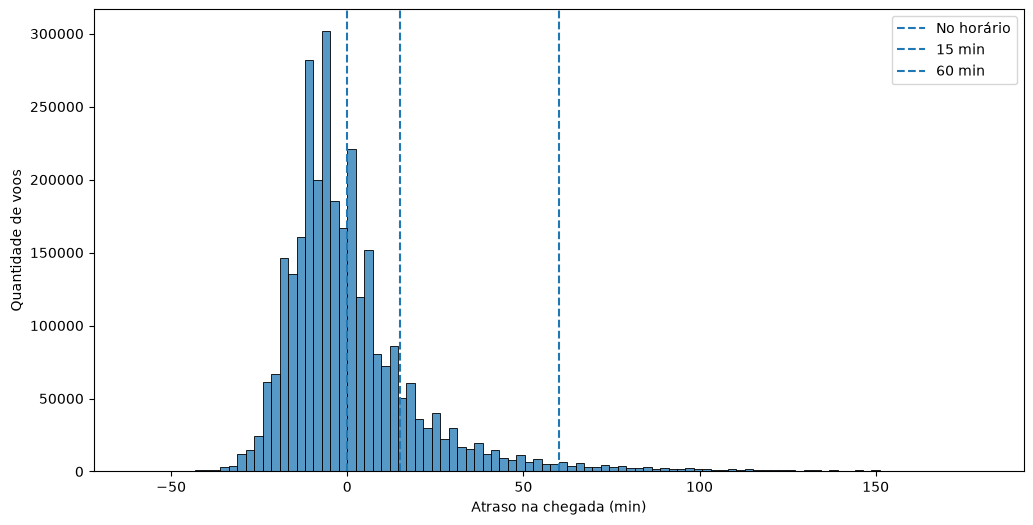

In [32]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data_delay[
        data_delay["arr_delay_min"].between(-60, 180)
    ]["arr_delay_min"],
    bins=100
)

plt.axvline(0, linestyle="--", label="No horário")
plt.axvline(15, linestyle="--", label="15 min")
plt.axvline(60, linestyle="--", label="60 min")

plt.xlabel("Atraso na chegada (min)")
plt.ylabel("Quantidade de voos")
plt.legend()

plt.show()

In [34]:
bins = [
    -np.inf,
    0,
    15,
    60,
    np.inf
]

labels = [
    "Adiantado",
    "0-15",
    "15-60",
    "60+"
]

delay_class = pd.cut(
    data_delay["arr_delay_min"],
    bins=bins,
    labels=labels
)

(
    delay_class
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

arr_delay_min
Adiantado    61.94
0-15         22.60
15-60        12.56
60+           2.90
Name: proportion, dtype: float64